© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note about the Synthetic Signal**:
The synthetic signal generated using this notebook that are **identical to or derivative of those published in**:     
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in press**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such data requires explicit permission from the journal.  
 
Synthetic signals that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

The wavelength grid spans: [299.725, 300.088] nm (guard=0.050 nm)


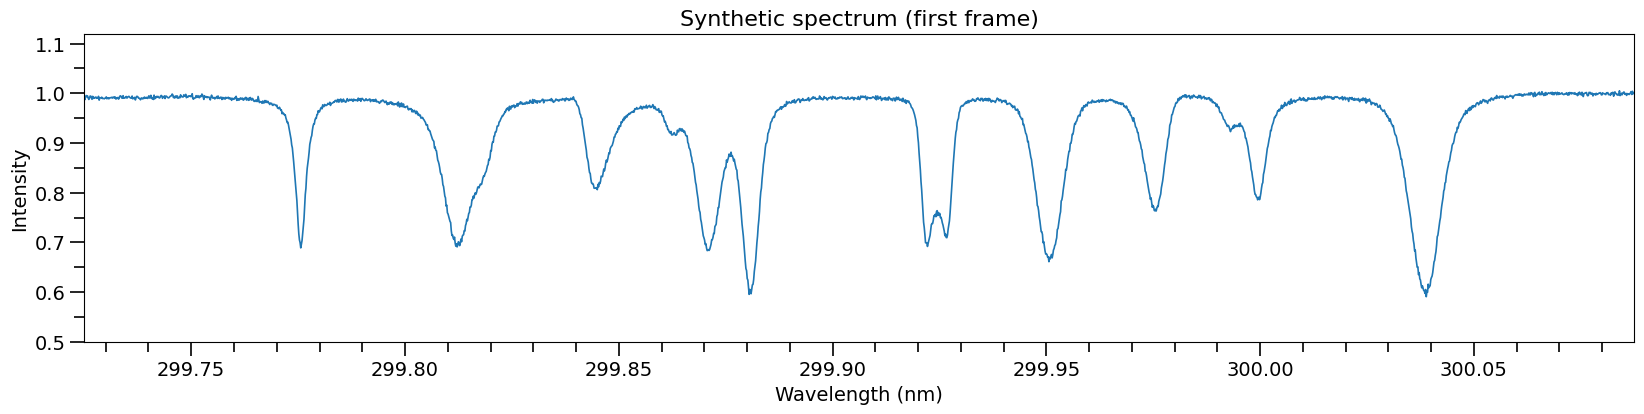

Saved FITS: synthetic_nuv_testbed.fits

Velocity summary (after smooth rescale-to-cap; NO clipping):
Line  0: lambda0=299.775000 nm  max|v|=  2.214 km/s  max|Δλ|=0.002214 nm  at it=138 (t=1380.0 s)
Line  1: lambda0=299.812500 nm  max|v|=  2.800 km/s  max|Δλ|=0.002800 nm  at it=125 (t=1250.0 s)
Line  2: lambda0=299.845000 nm  max|v|=  2.200 km/s  max|Δλ|=0.002200 nm  at it=276 (t=2760.0 s)
Line  3: lambda0=299.870000 nm  max|v|=  2.600 km/s  max|Δλ|=0.002601 nm  at it=149 (t=1490.0 s)
Line  4: lambda0=299.880000 nm  max|v|=  2.600 km/s  max|Δλ|=0.002601 nm  at it=114 (t=1140.0 s)
Line  5: lambda0=299.925000 nm  max|v|=  1.200 km/s  max|Δλ|=0.001201 nm  at it=188 (t=1880.0 s)
Line  6: lambda0=299.950000 nm  max|v|=  1.800 km/s  max|Δλ|=0.001801 nm  at it=14 (t=140.0 s)
Line  7: lambda0=299.975000 nm  max|v|=  1.815 km/s  max|Δλ|=0.001816 nm  at it=208 (t=2080.0 s)
Line  8: lambda0=300.000000 nm  max|v|=  1.950 km/s  max|Δλ|=0.001951 nm  at it=102 (t=1020.0 s)
Line  9: lambda0=300.037500 

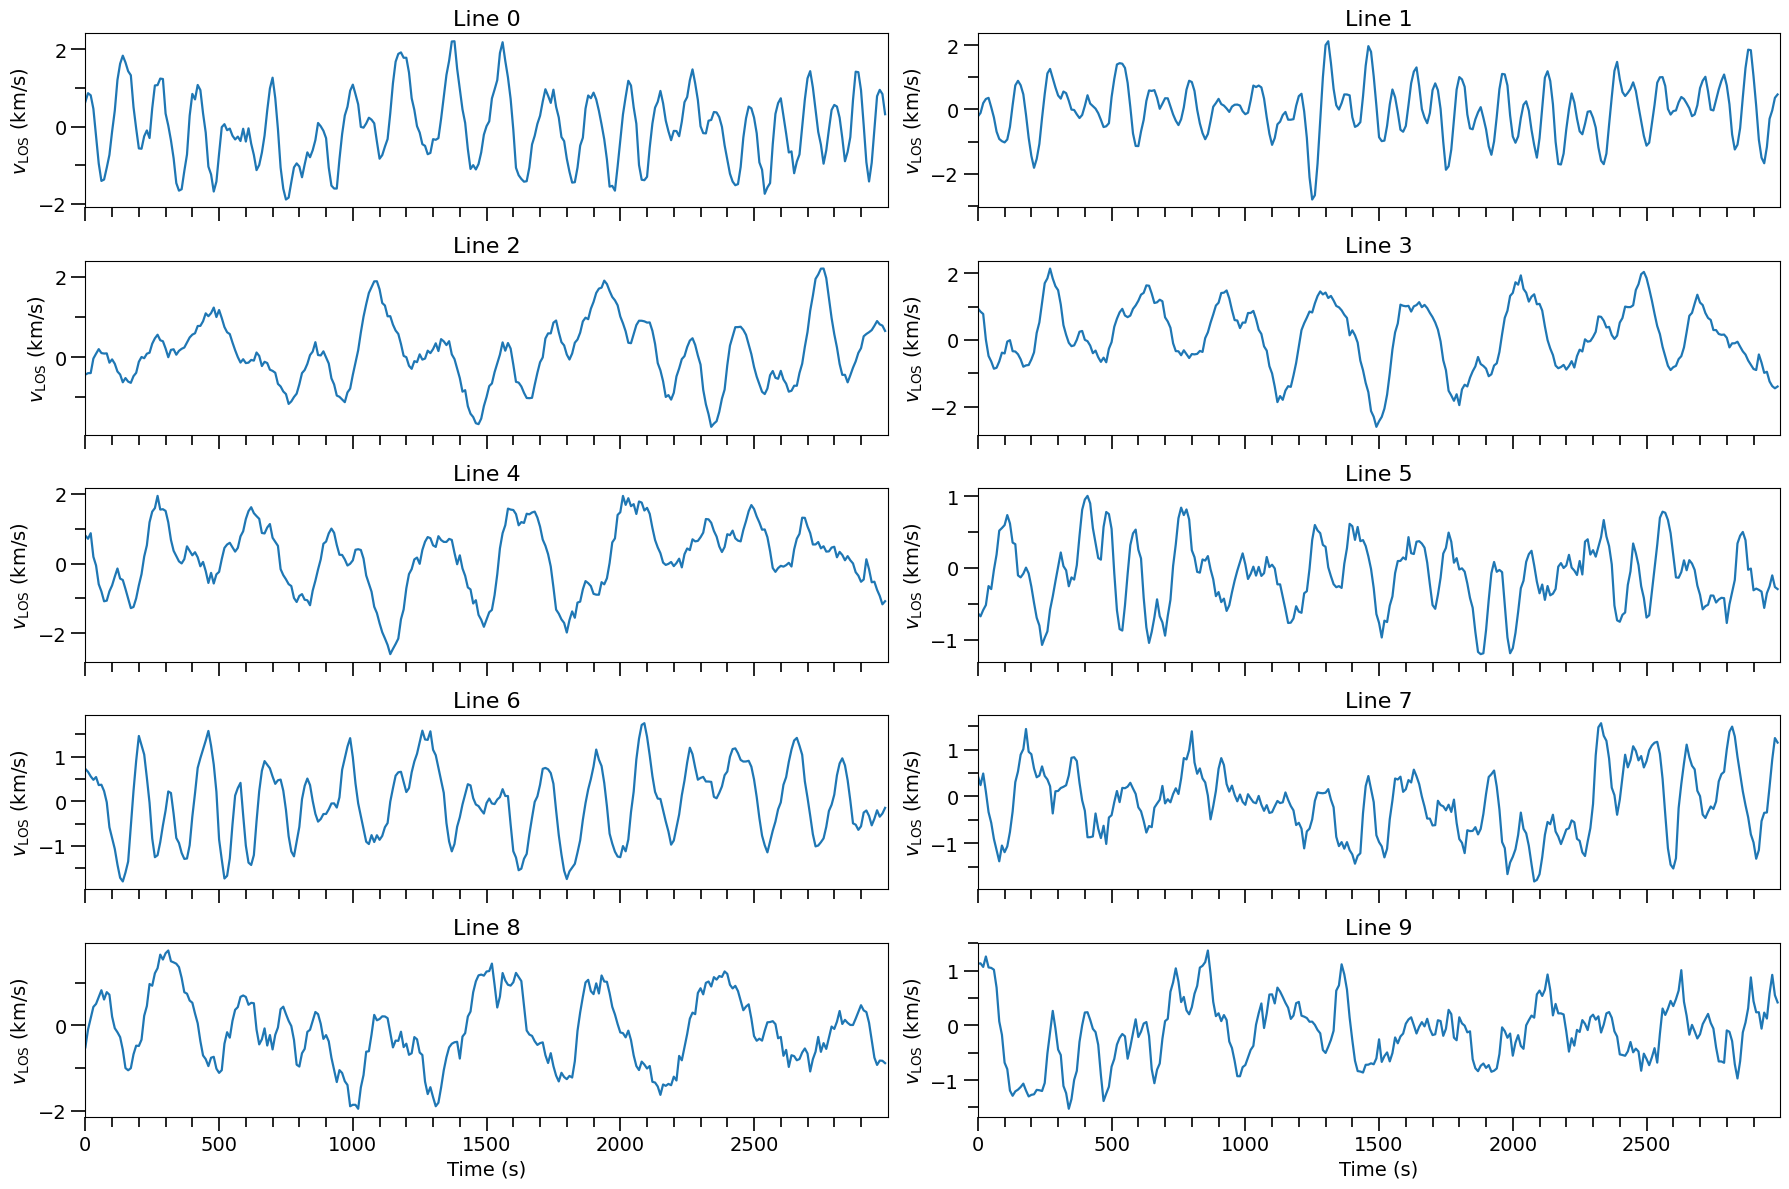

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Synthetic multi-line near-UV (NUV) spectral testbed
====================================================

Purpose
-------
This script generates a reproducible synthetic time series of multi-line
near-UV spectra intended for benchmarking spectral-line tracking and fitting routines
(e.g. WaLSA LineFit) under realistic complications:

  • multiple absorption lines with different widths/depths
  • line blends/contaminants
  • asymmetric profiles (including asymmetry that starts at the core)
  • a complex “split + emission” line (morphs between single and split regimes)
  • time-dependent Doppler shifts (ground-truth v_LOS per line)
  • time variability in line depth and width (AR(1)-type modulation)
  • optional continuum slope + ripple
  • optional spectral PSF convolution along wavelength
  • optional noise with enhanced amplitude in line cores

Design goals
------------
• Paper-/repo-friendly: parameters are explicit, documented, and saved to FITS headers
  (compact summary) + truth extensions (full numeric arrays).
• Benchmark-friendly: produces “truth” centers and velocities per line and time.
• Reproducible: controlled via a single random seed, with intentional legacy choices
  documented where reproducibility constraints exist (e.g., blend RNG behaviour).

Outputs
-------
1) In-memory objects:
   wavelengths : (nw,) float [nm]
   spectra     : (nt, nw) float, intensity-like in [0, 1.2]
   meta        : list of dicts, per-line parameters actually used (after overrides)
   truth       : dict with time axis, truth velocities, truth centers, and variability drivers

2) FITS file:
   synthetic_nuv_testbed.fits
   • Primary HDU: spectra cube (nt, nw)
   • Extensions:
       - WAVELENGTH : wavelength axis [nm]
       - TIME       : time axis [s]
       - LAMBDA0    : rest centers of the 10 primary lines [nm]
       - V_TRUE     : truth velocities per line and time [km/s] (10, nt)
       - CENTER_TRUE: truth centers per line and time [nm] (10, nt)
       - SPLIT_STRENGTH : (nt,)
       - EMIS_STRENGTH  : (nt,)
   • Header keywords carry key generation parameters + per-line compact summary.

3) Plots:
  (a) first spectrum frame
  (b) truth velocity time series for all 10 lines

Reproducibility notes
---------------------
• The “reference spectrum” configuration (as used in the paper) is achieved by:
  - fixed `line_params` (per-line baseline shapes + optional constraints)
  - fixed `lambda0_nm` (absolute line placement)
  - fixed seed
• Some behaviours are intentionally “legacy reproducibility” choices:
  - Blend contaminants use a *fresh RNG per blend* (seed + 123 + b) each time step.
    This is kept as-is because it was already part of the reference behaviour.

Dependencies
------------
numpy, matplotlib, scipy, astropy

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.special import wofz
from scipy.ndimage import gaussian_filter1d
from astropy.io import fits
from matplotlib.ticker import AutoMinorLocator

# Speed of light in km/s
C_KMS = 299792.458

# =============================================================================
# 1) Line-shape primitives
# =============================================================================
def voigt_shape(lam_nm: np.ndarray, lam0_nm: float, sigma_nm: float, gamma_nm: float) -> np.ndarray:
    """
    Peak-normalized Voigt profile (maximum = 1).

    Parameters
    ----------
    lam_nm : array
        Wavelength array [nm].
    lam0_nm : float
        Line center [nm].
    sigma_nm : float
        Gaussian sigma of the Voigt [nm] (controls Doppler/thermal broadening).
    gamma_nm : float
        Lorentzian HWHM of the Voigt [nm] (controls damping/pressure broadening).

    Returns
    -------
    V : array
        Voigt profile normalized to max(V) = 1.
    """
    sigma_nm = max(float(sigma_nm), 1e-7)
    gamma_nm = max(float(gamma_nm), 1e-7)
    z = ((lam_nm - lam0_nm) + 1j * gamma_nm) / (sigma_nm * np.sqrt(2.0))
    V = np.real(wofz(z)) / (sigma_nm * np.sqrt(2.0 * np.pi))
    V /= np.max(V)
    return V


def absorption_voigt(lam_nm: np.ndarray, depth: float, lam0_nm: float, sigma_nm: float, gamma_nm: float) -> np.ndarray:
    """
    Absorption depression using a Voigt profile.

    depth is the peak depression (roughly; exact depends on normalization).
    """
    return float(depth) * voigt_shape(lam_nm, lam0_nm, sigma_nm, gamma_nm)


def absorption_core_skew_voigt(
    lam_nm: np.ndarray,
    depth: float,
    lam0_nm: float,
    sigma_nm: float,
    gamma_nm: float,
    skew: float = 1.2,
    skew_width_nm: float = 0.0025,
) -> np.ndarray:
    """
    Voigt absorption with *core-starting* asymmetry.

    We skew the depression itself with a smooth odd function around lam0:

        D(lam) = depth * V(lam) * (1 + skew * tanh((lam - lam0)/skew_width))

    Notes
    -----
    • skew > 0 strengthens absorption on the red side and weakens on the blue side.
    • skew < 0 does the opposite (blue asymmetry).
    • skew_width_nm controls how rapidly the asymmetry turns on near the core.

    We clip to avoid negative depression and renormalize so 'depth' remains comparable.
    """
    V = voigt_shape(lam_nm, lam0_nm, sigma_nm, gamma_nm)
    s = float(skew)
    w = max(float(skew_width_nm), 1e-7)
    skew_factor = 1.0 + s * np.tanh((lam_nm - lam0_nm) / w)

    D = float(depth) * V * np.clip(skew_factor, 0.0, None)

    if np.max(D) > 0:
        D = D * (float(depth) / np.max(D))
    return D


def split_with_emission(
    lam_nm: np.ndarray,
    lam0_nm: float,
    depth_main: float,
    sigma_nm: float,
    gamma_nm: float,
    sep_nm: float,
    ratio_secondary: float,
    emis_amp: float,
    emis_sigma_nm: float,
    secondary_width_scale: float = 1.00,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Construct a complex line made of:
      • two absorption dips separated by sep_nm around lam0_nm
      • a central emission bump

    Parameters
    ----------
    sep_nm : float
        Separation between the two dips [nm] (total separation).
    ratio_secondary : float
        Depth ratio for the secondary dip (relative to main dip).
    emis_amp : float
        Peak amplitude of the emission bump (added back to intensity).
    emis_sigma_nm : float
        Sigma of the emission Gaussian [nm].
    secondary_width_scale: float
        Multiplies (sigma_nm, gamma_nm) for the SECONDARY dip only.

    Returns
    -------
    dip_sum : array
        Total absorption depression from both dips.
    emis : array
        Emission component to be added to intensity.
    """
    sws = float(secondary_width_scale)

    dip1 = absorption_voigt(
        lam_nm, depth_main, lam0_nm - 0.5 * sep_nm, sigma_nm, gamma_nm
    )

    dip2 = absorption_voigt(
        lam_nm,
        depth_main * ratio_secondary,
        lam0_nm + 0.5 * sep_nm,
        sigma_nm * sws,
        gamma_nm * sws,
    )

    emis_sigma_nm = max(float(emis_sigma_nm), 1e-7)
    emis = float(emis_amp) * np.exp(-0.5 * ((lam_nm - lam0_nm) / emis_sigma_nm) ** 2)

    return dip1 + dip2, emis


def deepest_offset_nm(
    lam_nm: np.ndarray,
    lam0_nm: float,
    depth: float,
    sigma_nm: float,
    gamma_nm: float,
    skew: float,
    skew_width_nm: float,
) -> float:
    """
    Return delta (nm) such that the deepest absorption occurs at lam0_nm + delta.

    We compute the absorption depression D(lam) (positive), find argmax(D),
    and return (lam_at_deepest - lam0_nm).
    """
    D = absorption_core_skew_voigt(
        lam_nm, depth, lam0_nm, sigma_nm, gamma_nm,
        skew=skew, skew_width_nm=skew_width_nm
    )
    j = int(np.nanargmax(D))
    return float(lam_nm[j] - lam0_nm)


# =============================================================================
# 2) Stochastic evolution (time-series drivers)
# =============================================================================
def ar1_process(
    rng: np.random.Generator,
    nt: int,
    mu: float,
    sigma: float,
    phi: float = 0.97,
    clip: tuple[float, float] | None = None,
) -> np.ndarray:
    """
    AR(1) process:
        x[t] = mu + phi*(x[t-1] - mu) + N(0, sigma)

    Parameters
    ----------
    mu : float
        Mean value of the process.
    sigma : float
        Innovation noise standard deviation.
    phi : float
        Autoregressive coefficient; close to 1 => slow variations.
    clip : (lo, hi) or None
        Optional clipping bounds.

    Returns
    -------
    x : (nt,) array
    """
    x = np.zeros(nt, dtype=float)
    x[0] = float(mu)
    for k in range(1, nt):
        x[k] = mu + phi * (x[k - 1] - mu) + rng.normal(0.0, sigma)
    if clip is not None:
        x = np.clip(x, clip[0], clip[1])
    return x


def nonstationary_velocity_multifreq(
    rng: np.random.Generator,
    t_s: np.ndarray,
    *,
    # number of sinusoidal components
    nfreq_range: tuple[int, int] = (3, 6),  # randint(low, high) high exclusive -> 3..5

    # component frequency range (mHz)
    f_mhz_range: tuple[float, float] = (2.0, 9.0),

    # overall target amplitude scale (km/s) before envelopes/jitter/events
    amp_range: tuple[float, float] = (1.0, 4.0),

    # amplitude envelope AR(1) (per component)
    amp_env_phi: float = 0.995,
    amp_env_rel_sigma: float = 0.08,   # relative to component base amplitude

    # frequency wander AR(1) (shared, mild)
    f_env_phi: float = 0.995,
    f_env_rel_sigma: float = 0.03,     # relative to each component f0

    # jitter AR(1)
    jitter_phi: float = 0.92,
    jitter_sigma: float = 0.20,
    jitter_clip: tuple[float, float] = (-1.5, 1.5),

    # events (impulses smoothed)
    n_events_range: tuple[int, int] = (2, 6),
    event_amp_sigma: float = 1.0,
    event_smooth_sigma: float = 2.0,
    event_weight: float = 0.35,

) -> np.ndarray:
    """
    Generate a multi-frequency, nonstationary v_LOS(t) signal (km/s) with:
      • oscillatory component with slowly varying amplitude and frequency
      • AR(1) jitter
      • sporadic impulses smoothed into short-lived events

    Returns
    -------
    v : (nt,) array [km/s]
    """
    nt = len(t_s)
    dt = float(t_s[1] - t_s[0])

    nfreq = int(rng.integers(nfreq_range[0], nfreq_range[1]))  # 3..5
    # Draw base frequencies and amplitudes
    f0_mhz = rng.uniform(f_mhz_range[0], f_mhz_range[1], size=nfreq)
    # Spread component amplitudes but control by a total scale
    amp_total = float(rng.uniform(*amp_range))
    w = rng.uniform(0.4, 1.0, size=nfreq)
    w = w / np.sum(w)
    a0 = amp_total * w * float(rng.uniform(0.8, 1.2))  # slight extra variability

    # Per-component amplitude envelopes
    amp_env = np.zeros((nfreq, nt), float)
    for j in range(nfreq):
        amp_env[j] = ar1_process(
            rng, nt,
            mu=a0[j],
            sigma=amp_env_rel_sigma * max(a0[j], 1e-6),
            phi=amp_env_phi,
            clip=(0.0, 8.0),
        )

    # Per-component frequency wander (mHz), mild
    f_mhz = np.zeros((nfreq, nt), float)
    for j in range(nfreq):
        f_mhz[j] = ar1_process(
            rng, nt,
            mu=float(f0_mhz[j]),
            sigma=f_env_rel_sigma * max(float(f0_mhz[j]), 1e-6),
            phi=f_env_phi,
            clip=(0.5, 12.0),
        )
    f_hz = f_mhz * 1e-3

    # Integrate phase per component
    phase = np.zeros((nfreq, nt), float)
    phase[:, 0] = rng.uniform(0.0, 2.0 * np.pi, size=nfreq)
    for k in range(1, nt):
        phase[:, k] = phase[:, k - 1] + 2.0 * np.pi * f_hz[:, k] * dt

    osc = np.sum(amp_env * np.sin(phase), axis=0)

    # Jitter (low-frequency)
    jitter = ar1_process(
        rng, nt,
        mu=0.0,
        sigma=jitter_sigma,
        phi=jitter_phi,
        clip=jitter_clip,
    )

    # Events
    events = np.zeros(nt, float)
    n_events = int(rng.integers(n_events_range[0], n_events_range[1]))
    for _ in range(n_events):
        k0 = int(rng.integers(0, nt))
        events[k0] += rng.normal(0.0, event_amp_sigma)
    events = gaussian_filter1d(events, sigma=event_smooth_sigma)

    return osc + jitter + event_weight * events


def rescale_to_cap(v: np.ndarray, cap_kms: float) -> np.ndarray:
    """
    Smooth cap enforcement: multiply the whole series by a single factor so max|v|<=cap.
    (No clipping -> no step artifacts.)
    """
    v = np.asarray(v, float)
    cap = float(cap_kms)
    m = float(np.nanmax(np.abs(v)))
    if (not np.isfinite(m)) or m <= 0 or (not np.isfinite(cap)) or cap <= 0:
        return v
    if m <= cap:
        return v
    s = cap / m
    return v * s


# =============================================================================
# 3) Generator
# =============================================================================
def generate_testbed(
    # ---- wavelength grid ----
    lam_center_nm: float = 300.0,
    window_nm: float = 0.80,
    nw: int = 2400,

    lambda0_nm=None,    # optional: absolute line centers, array length 10
    lam_min_nm=None,    # optional: explicit wavelength range start
    lam_max_nm=None,    # optional: explicit wavelength range end

    # ---- time axis ----
    dt: float = 10.0,
    nt: int = 300,

    # ---- instrumental effects ----
    spectral_psf_fwhm_nm: float | None = 0.0020,

    # ---- continuum ----
    continuum_slope: float = 0.02,
    add_ripple: bool = True,
    ripple_amp: float = 0.0015,
    ripple_period_nm: float = 0.035,

    # ---- noise ----
    add_noise: bool = True,
    noise_sigma_cont: float = 0.0018,
    noise_core_boost: float = 2.0,

    # ---- reproducibility ----
    seed: int = 7,

    # ---- line placement control ----
    offsets_nm: np.ndarray | None = None,   # NOTE: currently not used when lambda0_nm is provided (kept for API continuity)
    close_pair_sep_nm: float = 0.010,       # enforced lambda0[4] = lambda0[3] + sep

    # ---- per-line parameter control ----
    line_params: dict[int, dict] | None = None,

    # ---- time-series driver control (for paper transparency) ----
    depth_scale_ar1: dict | None = None,
    width_scale_ar1: dict | None = None,
    skew_ar1: dict | None = None,
    split_ar1: dict | None = None,
    emis_ar1: dict | None = None,

    # ---- velocity driver control ----
    velocity_driver: dict | None = None,

    # ---- per-line caps (km/s) ----
    V_CAP_PER_LINE: np.ndarray | None = None,

    # ---- convenience ----
    plot_first: bool = True,

    # ---- split-line behaviour control ----
    split_morph_sep_on_nm: float = 0.0030,
    split_morph_sep_full_nm: float = 0.0070,
    split_emission_follows_split: bool = True,
) -> tuple[np.ndarray, np.ndarray, list[dict], dict]:
    """
    Generate (wavelengths, spectra, meta, truth) for the synthetic NUV testbed.

    Key user controls
    -----------------
    lambda0_nm:
        Absolute control of primary line rest wavelengths (length 10).
        If provided, it overrides any internal spacing/offset construction.

    offsets_nm:
        Reserved/kept for API continuity. When lambda0_nm is NOT given, the code uses
        its own default offsets. (This parameter is not currently wired into that path.)

    line_params:
        Dict keyed by line index (0..9) that can override any of:
          depth0, sigma0, gamma0, skew0, skew_w0,
          split_sep0, split_ratio2_0, emis0, emis_sig0,
          plus any optional extra keys (e.g., depth_min, split_sigma_scale, ...).

        IMPORTANT: 'lambda0' in line_params is treated as documentation-only here;
        the generator does NOT allow overriding lambda0 via line_params (to avoid conflicts).
        Line placement is controlled solely by lambda0_nm (or internal lambda0 construction).

    Time-series drivers:
        Dicts controlling AR(1) variability for depth/width/skew/split/emission and
        the velocity driver parameters.

    Returns
    -------
    wavelengths : (nw,) [nm]
    spectra     : (nt, nw) intensity-like
    meta        : list of per-line dicts used
    truth       : dict with time axis, truth velocities, truth line centers, and driver arrays
    """

    rng = np.random.default_rng(seed)

    # ----------------------------
    # time axis + wavelength axis
    # ----------------------------
    # --- wavelength grid (either explicit range or center+window) ---
    if lam_min_nm is not None or lam_max_nm is not None:
        if lam_min_nm is None or lam_max_nm is None:
            raise ValueError("Provide both lam_min_nm and lam_max_nm (or neither).")
        lam_min = float(lam_min_nm)
        lam_max = float(lam_max_nm)
    else:
        lam_min = lam_center_nm - 0.5 * window_nm
        lam_max = lam_center_nm + 0.5 * window_nm

    wavelengths = np.linspace(lam_min, lam_max, nw).astype(float)
    dlam = float(wavelengths[1] - wavelengths[0])
    t_s = np.arange(nt, dtype=float) * float(dt)

    # -------------------------
    # primary line placement
    # -------------------------
    # --- primary line rest wavelengths (absolute control) ---
    if lambda0_nm is not None:
        lambda0 = np.asarray(lambda0_nm, dtype=float)
        if lambda0.size != 10:
            raise ValueError("lambda0_nm must have length 10.")
    else:
        offsets = np.array([-0.34, -0.26, -0.18, -0.11, -0.04, 0.05, 0.08, 0.16, 0.22, 0.30]) * (window_nm/0.80)
        lambda0 = lam_center_nm + offsets

    # enforce close pair (line 4 is placed relative to line 3)
    lambda0[4] = lambda0[3] + float(close_pair_sep_nm)

    # -------------------------
    # line types
    # -------------------------
    line_types = [
        "clean_sym",         # 0
        "clean_med",         # 1
        "asym_core_skew",    # 2
        "close_pair_A",      # 3
        "close_pair_B",      # 4
        "split_emis",        # 5
        "clean_thin",        # 6
        "asym_strong_B",     # 7
        "clean_wide",        # 8
        "clean_sym2",        # 9
    ]

    # -------------------------------------------------
    # blend contaminants (not among the 10 primaries)
    # -------------------------------------------------
    blends = [
        {"host": 1, "dlam": +0.006, "depth": 0.10, "sigma": 0.0016, "gamma": 0.0010, "max_frac_of_host": 0.30},
        {"host": 3, "dlam": -0.008, "depth": 0.05, "sigma": 0.0012, "gamma": 0.0008, "max_frac_of_host": 0.40},
        {"host": 8, "dlam": -0.007, "depth": 0.06, "sigma": 0.0014, "gamma": 0.0009, "max_frac_of_host": 0.25},
    ]

    # -------------------------------------------
    # per-line parameters (frozen/overrideable)
    # -------------------------------------------
    if line_params is None:
        line_params = {}

    meta: list[dict] = []
    for i in range(10):
        typ = line_types[i]

        # Default draw ranges (legacy behaviour) — overridden below when line_params provides fixed values
        depth0 = rng.uniform(0.18, 0.42)
        if typ == "close_pair_B":
            depth0 *= 0.55

        sigma0 = rng.uniform(0.0014, 0.0035)
        gamma0 = rng.uniform(0.0009, 0.0028)
        if typ == "clean_thin":
            sigma0 *= 0.75
            gamma0 *= 0.75
        if typ == "clean_wide":
            sigma0 *= 1.8
            gamma0 *= 1.6

        skew0 = 1.4 if typ == "asym_core_skew" else (1.1 if typ == "asym_strong_B" else 0.0)
        skew_w0 = 0.0020 if typ == "asym_core_skew" else (0.0030 if typ == "asym_strong_B" else 0.0)

        split_sep0 = 0.010 if typ == "split_emis" else 0.0
        split_ratio2_0 = 0.65 if typ == "split_emis" else 0.0
        emis0 = 0.10 if typ == "split_emis" else 0.0
        emis_sig0 = 0.0020 if typ == "split_emis" else 0.0

        m = dict(
            i=i,
            type=typ,
            lambda0=float(lambda0[i]),
            depth0=float(depth0),
            sigma0=float(sigma0),
            gamma0=float(gamma0),
            skew0=float(skew0),
            skew_w0=float(skew_w0),
            split_sep0=float(split_sep0),
            split_ratio2_0=float(split_ratio2_0),
            emis0=float(emis0),
            emis_sig0=float(emis_sig0),
        )

        # Apply per-line overrides (frozen values for exact reproducibility)
        if i in line_params and isinstance(line_params[i], dict):
            for k, v in line_params[i].items():
                # IMPORTANT: do NOT allow line_params to override the line centres
                # (so lambda0_nm or the internally defined lambda0 stays in control)
                if k == "lambda0":
                    continue
                if k in m:
                    m[k] = float(v) if isinstance(m[k], (float, int)) else v
                else:
                    # allow future/ext params without breaking
                    m[k] = v

        meta.append(m)

    # =============================================================================
    # Time-dependent variability drivers (explicit + overrideable)
    # =============================================================================
    depth_scale_ar1 = depth_scale_ar1 or {"mu": 1.0, "sigma": 0.07, "phi": 0.985, "clip": (0.55, 1.70)}
    width_scale_ar1 = width_scale_ar1 or {"mu": 1.0, "sigma": 0.05, "phi": 0.985, "clip": (0.70, 1.60)}
    skew_ar1 = skew_ar1 or {"sigma": 0.10, "phi": 0.98, "clip": (0.2, 2.0)}

    split_ar1 = {"mu": 1.35, "sigma": 0.10, "phi": 0.985, "clip": (0.6, 1.8)}
    emis_ar1  = emis_ar1  or {"mu": 1.0, "sigma": 0.15, "phi": 0.98, "clip": (0.0, 2.2)}

    depth_scale = np.zeros((10, nt), float)
    width_scale = np.zeros((10, nt), float)
    skew_t = np.zeros((10, nt), float)

    for i, m in enumerate(meta):
        depth_scale[i] = ar1_process(rng, nt, **depth_scale_ar1)
        width_scale[i] = ar1_process(rng, nt, **width_scale_ar1)
        if "asym" in m["type"]:
            skew_t[i] = ar1_process(
                rng, nt,
                mu=m.get("skew0", 0.0),
                sigma=skew_ar1["sigma"],
                phi=skew_ar1["phi"],
                clip=skew_ar1["clip"],
            )
        else:
            skew_t[i] = 0.0

    split_strength = ar1_process(rng, nt, **split_ar1)
    emis_strength  = ar1_process(rng, nt, **emis_ar1)

    for _ in range(rng.integers(0, 2)):
        k0 = rng.integers(0, nt - 20)
        L = rng.integers(5, 15)
        split_strength[k0:k0+L] *= rng.uniform(0.5, 0.8)
        emis_strength[k0:k0+L]  *= rng.uniform(0.0, 0.35)

    blend_scale = np.zeros((len(blends), nt), float)
    for b in range(len(blends)):
        blend_scale[b] = ar1_process(rng, nt, mu=1.0, sigma=0.20, phi=0.95, clip=(0.0, 2.5))

    # Velocity driver parameters
    velocity_driver = velocity_driver or {
        # multi-frequency defaults (3–5 components) + 2–9 mHz
        "nfreq_range": (3, 6),
        "f_mhz_range": (2.0, 9.0),
        "amp_range": (1.5, 4.0),
        "amp_env_phi": 0.995,
        "amp_env_rel_sigma": 0.08,
        "f_env_phi": 0.995,
        "f_env_rel_sigma": 0.03,
        "jitter_phi": 0.92,
        "jitter_sigma": 0.20,
        "jitter_clip": (-1.5, 1.5),
        "n_events_range": (2, 6),
        "event_amp_sigma": 1.0,
        "event_smooth_sigma": 2.0,
        "event_weight": 0.35,
    }

    if V_CAP_PER_LINE is None:
        V_CAP_PER_LINE = np.array([3.5, 2.8, 2.2, 2.6, 2.6, 1.2, 1.8, 2.0, 3.0, 2.7], float)
    V_CAP_PER_LINE = np.asarray(V_CAP_PER_LINE, float)
    if V_CAP_PER_LINE.shape != (10,):
        raise ValueError("V_CAP_PER_LINE must be shape (10,) in km/s")

    # =============================================================================
    # Truth velocities and truth centers
    # =============================================================================
    v_true = np.zeros((10, nt), float)
    for i in range(10):
        v_raw = nonstationary_velocity_multifreq(rng, t_s, **velocity_driver)
        v_true[i] = rescale_to_cap(v_raw, V_CAP_PER_LINE[i])

    # --- Special handling for the close pair (lines 3 and 4) ---
    iA, iB = 3, 4

    # Choose a minimum allowed instantaneous separation (nm)
    sep_min_nm = 0.008
    sep0_nm = float(meta[iB]["lambda0"] - meta[iA]["lambda0"])

    # dv bounds so that (sep0 + lambda_bar * dv / c) >= sep_min
    lambda_bar = 0.5 * (meta[iA]["lambda0"] + meta[iB]["lambda0"])
    dv_min_kms = (sep_min_nm - sep0_nm) * C_KMS / lambda_bar  # negative
    dv_max_kms = +0.8

    # Differential drift dv(t) = vB - vA (AR(1), clipped)
    dv_pair = ar1_process(
        rng, nt,
        mu=0.0,
        sigma=0.15,
        phi=0.97,
        clip=(dv_min_kms, dv_max_kms),
    )

    # Set B from A + dv, then rescale both smoothly if B exceeds cap_B
    vB = v_true[iA] + dv_pair
    vB = rescale_to_cap(vB, V_CAP_PER_LINE[iB])
    # scaleA = min(1.0, V_CAP_PER_LINE[iA] / max(np.max(np.abs(v_true[iA])), 1e-12))
    # v_true[iA] *= scaleA
    v_true[iB] = vB

    # truth centers
    center_true = np.zeros((10, nt), float)
    for i, m in enumerate(meta):
        center_true[i] = m["lambda0"] * (1.0 + v_true[i] / C_KMS)

    # =============================================================================
    # Continuum model
    # =============================================================================
    cont = 1.0 + continuum_slope * (wavelengths - lam_center_nm) / window_nm
    if add_ripple:
        cont *= (1.0 + ripple_amp * np.sin(2.0 * np.pi * wavelengths / ripple_period_nm))

    # =============================================================================
    # Build spectra time series
    # =============================================================================
    spectra = np.zeros((nt, nw), float)

    for it in range(nt):
        I = cont.copy()

        # primary lines
        for i, m in enumerate(meta):
            lam0_t = center_true[i, it]
            depth = m["depth0"] * depth_scale[i, it]
            sigma = m["sigma0"] * width_scale[i, it]
            gamma = m["gamma0"] * width_scale[i, it]
            typ = m["type"]

            # Optional absolute minimum depth (e.g., for close_pair_B) to prevent vanishing lines
            depth_min = m.get("depth_min", None)
            if depth_min is not None:
                depth = max(float(depth), float(depth_min))

            if typ.startswith("clean") or typ.startswith("close_pair"):
                I -= absorption_voigt(wavelengths, depth, lam0_t, sigma, gamma)

            elif typ == "asym_core_skew":
                # Force the deepest point to be at lam0_t (truth centre).
                delta = deepest_offset_nm(
                    wavelengths, lam0_t, depth, sigma, gamma,
                    skew=skew_t[i, it],
                    skew_width_nm=m["skew_w0"],
                )
                lam0_eff = lam0_t - delta
                I -= absorption_core_skew_voigt(
                    wavelengths, depth, lam0_eff, sigma, gamma,
                    skew=skew_t[i, it], skew_width_nm=m["skew_w0"]
                )

            elif typ == "asym_strong_B":
                # Blue asymmetry: flip skew sign, but still force deepest point to be at lam0_t
                skew_here = -skew_t[i, it]
                skew_w = m["skew_w0"] if m["skew_w0"] > 0 else 0.003
                delta = deepest_offset_nm(
                    wavelengths, lam0_t, depth, sigma, gamma,
                    skew=skew_here,
                    skew_width_nm=skew_w,
                )
                lam0_eff = lam0_t - delta
                I -= absorption_core_skew_voigt(
                    wavelengths, depth, lam0_eff, sigma, gamma,
                    skew=skew_here, skew_width_nm=skew_w
                )

            elif typ == "split_emis":
                # Time-dependent split controls (kept as-is)
                sep = m["split_sep0"] * (0.15 + 1.10 * split_strength[it]**1.2)
                ratio2 = m["split_ratio2_0"] * (0.6 + 0.6 * split_strength[it])

                emis_amp = m["emis0"] * emis_strength[it] * (1.0 - 0.6 * split_strength[it])
                emis_amp = max(0.0, emis_amp)
                emis_sig = m["emis_sig0"]

                # MORPH between: (A) single Voigt <--> (B) split+emission
                if split_morph_sep_full_nm <= split_morph_sep_on_nm:
                    raise ValueError("split_morph_sep_full_nm must be > split_morph_sep_on_nm")

                sf = (sep - split_morph_sep_on_nm) / (split_morph_sep_full_nm - split_morph_sep_on_nm)
                sf = float(np.clip(sf, 0.0, 1.0))

                dip_single = absorption_voigt(wavelengths, depth, lam0_t, sigma, gamma)

                sigma_split = sigma * m.get("split_sigma_scale", 0.65)
                gamma_split = gamma * m.get("split_gamma_scale", 0.65)
                secondary_width_scale = m.get("split_secondary_width_scale", 1.00)

                dip_split, emis = split_with_emission(
                    wavelengths, lam0_t,
                    depth_main=depth,
                    sigma_nm=sigma_split, gamma_nm=gamma_split,
                    sep_nm=sep,
                    ratio_secondary=ratio2,
                    emis_amp=emis_amp,
                    emis_sigma_nm=emis_sig,
                    secondary_width_scale=secondary_width_scale,
                )

                if split_emission_follows_split:
                    emis = sf * emis

                dip = (1.0 - sf) * dip_single + sf * dip_split
                I -= dip
                I += emis

        # blend contaminants
        # NOTE: strict reproducibility: keep legacy behaviour that used a fresh RNG per blend
        for b, bl in enumerate(blends):
            host = bl["host"]
            lam_bl0 = meta[host]["lambda0"] + bl["dlam"]

            # contaminant velocity: correlated with host + small random term
            v_bl = 0.5 * v_true[host, it] + np.random.default_rng(seed + 123 + b).normal(0.0, 0.4)
            lam_bl_t = lam_bl0 * (1.0 + v_bl / C_KMS)

            blend_depth_inst = bl["depth"] * blend_scale[b, it]
            host_depth_inst = meta[host]["depth0"] * depth_scale[host, it]

            # Cap blend depth so it cannot rival the host line
            max_frac = bl.get("max_frac_of_host", None)
            if max_frac is not None:
                blend_depth_inst = min(blend_depth_inst, float(max_frac) * host_depth_inst)

            I -= absorption_voigt(
                wavelengths,
                depth=blend_depth_inst,
                lam0_nm=lam_bl_t,
                sigma_nm=bl["sigma"],
                gamma_nm=bl["gamma"],
            )

        spectra[it] = np.clip(I, 0.0, 1.2)

    # =============================================================================
    # Spectral PSF (convolution along wavelength)
    # =============================================================================
    if spectral_psf_fwhm_nm is not None and float(spectral_psf_fwhm_nm) > 0:
        sigma_nm = float(spectral_psf_fwhm_nm) / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        sigma_pix = float(sigma_nm / dlam)
        if np.isfinite(sigma_pix) and sigma_pix > 0:
            spectra = gaussian_filter1d(spectra, sigma=sigma_pix, axis=1, mode="nearest")

    # =============================================================================
    # Noise model
    # =============================================================================
    if add_noise:
        rng2 = np.random.default_rng(seed + 999)
        noise_sigma = float(noise_sigma_cont) * (1.0 + float(noise_core_boost) * (1.0 - spectra))
        spectra = np.clip(spectra + rng2.normal(0.0, noise_sigma), 0.0, 1.2)

    truth = dict(
        t_s=t_s,
        v_true_kms=v_true,
        lambda0_nm=np.array([m["lambda0"] for m in meta], dtype=float),
        center_true_nm=center_true,
        split_strength=split_strength,
        emis_strength=emis_strength,
        blend_scale=blend_scale,
        blends=blends,
        driver_params=dict(
            depth_scale_ar1=depth_scale_ar1,
            width_scale_ar1=width_scale_ar1,
            skew_ar1=skew_ar1,
            split_ar1=split_ar1,
            emis_ar1=emis_ar1,
            velocity_driver=velocity_driver,
            V_CAP_PER_LINE=V_CAP_PER_LINE,
        ),
    )

    if plot_first:
        plt.figure(figsize=(20, 4))
        plt.plot(wavelengths, spectra[0], lw=1.2)
        plt.xlabel("Wavelength (nm)", fontsize=14)
        plt.ylabel("Intensity", fontsize=14)
        plt.title("Synthetic spectrum (first frame)", fontsize=16)
        plt.ylim(0.5, 1.12)
        plt.xlim(lam_min_nm or lam_min, lam_max_nm or lam_max)
        ax = plt.gca()
        ax.tick_params(axis="both", which="major", length=10, width=1.2)
        ax.tick_params(axis="both", which="minor", length=7, width=1.2)
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.show()

    return wavelengths, spectra, meta, truth


# =============================================================================
# 4) FITS output helper
# =============================================================================
def save_testbed_to_fits(
    filename: str,
    wavelengths: np.ndarray,
    spectra: np.ndarray,
    meta: list[dict],
    truth: dict,
    primary_hdu_name: str = "SPECTRA",
) -> None:
    """
    Save the full synthetic time series to a FITS file.

    Layout
    ------
    Primary HDU: spectra (nt, nw)
    Extensions: WAVELENGTH, TIME, LAMBDA0, V_TRUE, CENTER_TRUE, SPLIT_STRENGTH, EMIS_STRENGTH

    Notes
    -----
    • meta is stored in the header only in summarized form (FITS headers are not ideal for long JSON).
      For full meta, keep it in the repo as a sidecar .json if desired.
    """
    spectra = np.asarray(spectra, dtype=np.float32)
    wavelengths = np.asarray(wavelengths, dtype=np.float64)
    t_s = np.asarray(truth["t_s"], dtype=np.float64)
    lambda0 = np.asarray(truth["lambda0_nm"], dtype=np.float64)
    v_true = np.asarray(truth["v_true_kms"], dtype=np.float32)
    center_true = np.asarray(truth["center_true_nm"], dtype=np.float64)
    split_strength = np.asarray(truth["split_strength"], dtype=np.float32)
    emis_strength = np.asarray(truth["emis_strength"], dtype=np.float32)

    h0 = fits.PrimaryHDU(spectra)
    h0.header["EXTNAME"] = primary_hdu_name
    h0.header["NT"] = spectra.shape[0]
    h0.header["NW"] = spectra.shape[1]
    h0.header["CUNIT1"] = "nm"
    h0.header["CUNIT2"] = "s"
    h0.header["COMMENT"] = "Synthetic NUV multi-line testbed time series."
    h0.header["COMMENT"] = "Primary HDU contains spectra (nt, nw)."

    for m in meta:
        i = int(m["i"])
        h0.header[f"L{i:02d}"] = (m["lambda0"], f"Line {i} nominal center [nm]")
        h0.header[f"D{i:02d}"] = (m["depth0"],  f"Line {i} depth0")
        h0.header[f"S{i:02d}"] = (m["sigma0"],  f"Line {i} sigma0 [nm]")
        h0.header[f"G{i:02d}"] = (m["gamma0"],  f"Line {i} gamma0 [nm]")
        if "asym" in m["type"]:
            h0.header[f"K{i:02d}"] = (m["skew0"],   f"Line {i} skew0")
            h0.header[f"W{i:02d}"] = (m["skew_w0"], f"Line {i} skew width [nm]")
        if m["type"] == "split_emis":
            h0.header[f"SP{i:02d}"] = (m["split_sep0"],     f"Line {i} split sep0 [nm]")
            h0.header[f"SR{i:02d}"] = (m["split_ratio2_0"], f"Line {i} split ratio2_0")
            h0.header[f"EA{i:02d}"] = (m["emis0"],          f"Line {i} emission amp0")
            h0.header[f"ES{i:02d}"] = (m["emis_sig0"],      f"Line {i} emission sigma0 [nm]")

    hdus = [h0]
    hdus.append(fits.ImageHDU(wavelengths, name="WAVELENGTH"))
    hdus.append(fits.ImageHDU(t_s, name="TIME"))
    hdus.append(fits.ImageHDU(lambda0, name="LAMBDA0"))
    hdus.append(fits.ImageHDU(v_true, name="V_TRUE"))
    hdus.append(fits.ImageHDU(center_true, name="CENTER_TRUE"))
    hdus.append(fits.ImageHDU(split_strength, name="SPLIT_STRENGTH"))
    hdus.append(fits.ImageHDU(emis_strength, name="EMIS_STRENGTH"))

    fits.HDUList(hdus).writeto(filename, overwrite=True)


# =============================================================================
# 5) Reference configuration (default frozen parameters + spacing)
# =============================================================================
line_params = {
    0: {"type": "clean_sym",     "lambda0": 299.66,    "depth0": 0.300, "sigma0": 0.000284, "gamma0": 0.001374,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    1: {"type": "clean_med",     "lambda0": 299.74000, "depth0": 0.294, "sigma0": 0.002030, "gamma0": 0.002560,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    2: {"type": "asym_core_skew","lambda0": 299.82000, "depth0": 0.181, "sigma0": 0.003125, "gamma0": 0.002414,
        "skew0": 1.100, "skew_w0": 0.002000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    3: {"type": "close_pair_A",  "lambda0": 299.89000, "depth0": 0.292, "sigma0": 0.002036, "gamma0": 0.001429,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    4: {"type": "close_pair_B",  "lambda0": 299.90000, "depth0": 0.383, "sigma0": 0.001335, "gamma0": 0.001259,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000,
        "depth_min": 0.21},
    5: {"type": "split_emis",    "lambda0": 300.05000, "depth0": 0.413, "sigma0": 0.0014,   "gamma0": 0.0007,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.0030, "split_ratio2_0": 0.65, "emis0": 0.01, "emis_sig0": 0.001100,
        "split_sigma_scale": 0.65, "split_gamma_scale": 0.65, "split_secondary_width_scale": 1.0},
    6: {"type": "clean_thin",    "lambda0": 300.13000, "depth0": 0.329, "sigma0": 0.002608, "gamma0": 0.000982,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    7: {"type": "asym_strong_B", "lambda0": 300.21000, "depth0": 0.228, "sigma0": 0.002686, "gamma0": 0.000983,
        "skew0": 1.100, "skew_w0": 0.003000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    8: {"type": "clean_wide",    "lambda0": 300.28000, "depth0": 0.209, "sigma0": 0.001006, "gamma0": 0.001657,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
    9: {"type": "clean_sym2",    "lambda0": 300.35000, "depth0": 0.400, "sigma0": 0.002721, "gamma0": 0.001877,
        "skew0": 0.000, "skew_w0": 0.000000, "split_sep0": 0.000000, "split_ratio2_0": 0.00, "emis0": 0.000, "emis_sig0": 0.000000},
}

lam_center = 299.90
spacing_nm = 0.025
lambda0_nm = lam_center + spacing_nm * np.array([-5, -3.5, -2.2, -1.2, 0, 1, 2, 3, 4, 5.5], dtype=float)
lambda0_nm[4] = lambda0_nm[3] + 0.016

v_guard_kms = 10.0
doppler_guard_nm = (np.max(lambda0_nm) * v_guard_kms / C_KMS)
blend_guard_nm   = 0.010
base_margin_nm   = 0.030
guard_nm = base_margin_nm + doppler_guard_nm + blend_guard_nm
lam_min_nm = float(np.min(lambda0_nm) - guard_nm)
lam_max_nm = float(np.max(lambda0_nm) + guard_nm)
print(f"The wavelength grid spans: [{lam_min_nm:.3f}, {lam_max_nm:.3f}] nm (guard={guard_nm:.3f} nm)")

# =============================================================================
# 6) Generate + save FITS
# =============================================================================
add_noise = True

V_CAP_PER_LINE = np.array([3.5, 2.8, 2.2, 2.6, 2.6, 1.2, 1.8, 2.0, 3.0, 2.7], float)  # km/s

wavelengths, spectra, meta, truth = generate_testbed(
    lam_min_nm=lam_min_nm,
    lam_max_nm=lam_max_nm,
    nw=2400,
    dt=10.0,
    nt=300,
    spectral_psf_fwhm_nm=None,
    continuum_slope=0.02,
    add_ripple=True,
    ripple_amp=0.0015,
    ripple_period_nm=0.035,
    add_noise=add_noise,
    noise_sigma_cont=0.0021,
    noise_core_boost=2.0,
    seed=7,
    lambda0_nm=lambda0_nm,
    line_params=line_params,
    V_CAP_PER_LINE=V_CAP_PER_LINE,
    plot_first=True,
)

out_fits = "synthetic_nuv_testbed.fits" if add_noise else "synthetic_nuv_testbed_without_noise.fits"
save_testbed_to_fits(out_fits, wavelengths, spectra, meta, truth)
print(f"Saved FITS: {out_fits}")

# =============================================================================
# 7) Quick summary + PLOT truth velocity time series for all 10 lines
# =============================================================================
v_true_kms = truth["v_true_kms"]          # (10, nt)
t_s        = truth["t_s"]

vabs = np.nanmax(np.abs(v_true_kms), axis=1)
imax = np.nanargmax(np.abs(v_true_kms), axis=1)
dlam_abs = truth["lambda0_nm"] * vabs / C_KMS

print("\nVelocity summary (after smooth rescale-to-cap; NO clipping):")
for i in range(10):
    it = int(imax[i])
    print(
        f"Line {i:2d}: lambda0={truth['lambda0_nm'][i]:.6f} nm  "
        f"max|v|={vabs[i]:7.3f} km/s  max|Δλ|={dlam_abs[i]:.6f} nm  "
        f"at it={it} (t={t_s[it]:.1f} s)"
    )

# Plot v(t) for all 10 lines
fig, axs = plt.subplots(5, 2, figsize=(18, 12), sharex=True)
axs = axs.ravel()

for i in range(10):
    ax = axs[i]
    ax.plot(t_s, v_true_kms[i], lw=1.6)
    ax.set_title(f"Line {i}", fontsize=16)
    ax.set_ylabel(r"$v_{\rm LOS}$ (km/s)", fontsize=14)
    ax.tick_params(axis="both", which="major", length=10, width=1.2)
    ax.tick_params(axis="both", which="minor", length=7, width=1.2)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlim(0, 2999)

for ax in axs[-2:]:
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# =================================================================================
# Make an MP4 time-series movie of the spectrum with TRUE line centres overplotted
# =================================================================================
# Requirements:
#   - ffmpeg installed and available on PATH (most Macs: `brew install ffmpeg`)
#   - matplotlib (uses FFMpegWriter)
#
# Inputs assumed already in memory from the generator:
#   wavelengths : (nw,)
#   spectra     : (nt, nw)
#   truth["t_s"]           : (nt,)
#   truth["center_true_nm"]: (n_lines, nt)   # TRUE Doppler-shifted centres (per line, per time)
#
# Output:
#   synthetic_spectrum_timeseries.mp4
# ================================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.ticker import AutoMinorLocator
from astropy.io import fits


def make_spectrum_movie_mp4(
    wavelengths,
    spectra,
    truth,
    out_mp4="synthetic_spectrum_timeseries.mp4",
    fps=20,
    dpi=150,
    stride=1,
    ylim=None,
    xlim=None,
    lw_spec=1.2,
    lw_vline=1.1,
    alpha_vline=0.8,
    vline_ls="--",
):
    wavelengths = np.asarray(wavelengths, dtype=float)
    spectra = np.asarray(spectra, dtype=float)

    t_s = np.asarray(truth["t_s"], dtype=float)
    centers = np.asarray(truth["center_true_nm"], dtype=float)  # (n_lines, nt)

    nt, nw = spectra.shape
    n_lines = centers.shape[0]

    if centers.shape[1] != nt:
        raise ValueError(
            f"truth['center_true_nm'] has nt={centers.shape[1]} but spectra has nt={nt}."
        )

    # Frame indices (optionally decimate)
    frame_idx = np.arange(0, nt, stride, dtype=int)

    # Axis limits
    if xlim is None:
        xlim = (wavelengths[0], wavelengths[-1])

    if ylim is None:
        # robust-ish default based on full cube
        ylo = np.nanpercentile(spectra, 0.5)
        yhi = np.nanpercentile(spectra, 99.5)
        pad = 0.05 * (yhi - ylo) if np.isfinite(yhi - ylo) and (yhi > ylo) else 0.1
        ylim = (ylo - pad, yhi + pad)

    # Figure
    fig = plt.figure(figsize=(18, 4))
    ax = plt.gca()

    # ---- REMOVE EMPTY SPACE AROUND THE FIGURE ----
    fig.subplots_adjust(left=0.048, right=0.995, bottom=0.185, top=0.90)

    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    # Initial spectrum line
    (spec_line,) = ax.plot(
        wavelengths, spectra[frame_idx[0]], lw=lw_spec, zorder=1
    )

    # Initial vlines for true centres (one per line)  ---- BLACK vlines ----
    vlines = []
    for j in range(n_lines):
        x0 = centers[j, frame_idx[0]]
        if np.isfinite(x0):
            ln = ax.axvline(
                x0,
                ls=vline_ls,
                lw=lw_vline,
                alpha=alpha_vline,
                color="k",
                zorder=2,
            )
        else:
            ln = ax.axvline(
                wavelengths[0],
                ls=vline_ls,
                lw=lw_vline,
                alpha=0.0,
                color="k",
                zorder=2,  # invisible placeholder
            )
        vlines.append(ln)

    ax.set_xlim(299.760, 300.060)
    ax.set_xticks(np.arange(299.770, 300.060, 0.04))

    ax.set_ylim(*ylim)

    ax.tick_params(axis="both", which="major", length=10, width=1.4, pad=5, labelsize=16)
    ax.tick_params(axis="x", which="major", pad=8)
    ax.tick_params(axis="both", which="minor", length=6, width=1.4)
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.set_xlabel("Wavelength (nm)", fontsize=17)
    ax.set_ylabel("Normalised Intensity", fontsize=17)

    title = ax.set_title("", fontsize=18)

    # ---------------------------------------------------------------------
    # Markers + labels:
    #   - small white circle with black border
    #   - text label drawn ON TOP of the circle (zorder higher than circle)
    # ---------------------------------------------------------------------
    markers = []
    texts = []

    y_circle = ylim[1] - 0.080 * (ylim[1] - ylim[0])
    y_text = ylim[1] - 0.085 * (ylim[1] - ylim[0])

    for j in range(n_lines):
        # circle
        (mk,) = ax.plot(
            [wavelengths[0]],
            [y_circle],
            marker="o",
            markersize=24,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.0,
            linestyle="None",
            alpha=1.0,   
            zorder=6,
        )
        markers.append(mk)

        # text on top of circle (zorder > circle)
        tx = ax.text(
            wavelengths[0],
            y_text,
            "",
            fontsize=14,
            ha="center",
            va="center",
            color="black",
            alpha=1.0,  
            zorder=7,
        )
        texts.append(tx)

    def _update(frame_i):
        it = frame_idx[frame_i]

        # Update spectrum
        y = spectra[it]
        spec_line.set_ydata(y)

        # Update vlines + markers + text labels
        for j in range(n_lines):
            x = centers[j, it]
            if np.isfinite(x):
                vlines[j].set_xdata([x, x])
                vlines[j].set_alpha(alpha_vline)

                markers[j].set_data([x], [y_circle])
                markers[j].set_alpha(1.00)

                texts[j].set_position((x, y_text))
                texts[j].set_text(f"{j+1}")  # 1..n_lines
                texts[j].set_alpha(1.00)
            else:
                vlines[j].set_alpha(0.0)
                markers[j].set_alpha(0.0)
                texts[j].set_text("")
                texts[j].set_alpha(0.0)

        title.set_text(f"Synthetic spectrum | frame {it:4d}/{nt-1} | t = {t_s[it]:.1f} s")

        # Return artists for blitting
        return (spec_line, title, *vlines, *markers, *texts)

    anim = FuncAnimation(
        fig,
        _update,
        frames=len(frame_idx),
        interval=1000 / fps,
        blit=True,
        repeat=False,
    )

    writer = FFMpegWriter(fps=fps, metadata={"artist": "WaLSA Team / Shahin Jafarzadeh"}, bitrate=5000)
    anim.save(out_mp4, writer=writer, dpi=dpi)
    plt.close(fig)

    print(f"Saved movie: {out_mp4}")
    print(f"Frames: {len(frame_idx)} (stride={stride}), fps={fps}, duration≈{len(frame_idx)/fps:.1f} s")

# ---------------------------------------------------------------------------------------------------------

fits_path = "synthetic_nuv_testbed.fits"
with fits.open(fits_path) as hdul:
    spectra        = np.asarray(hdul[0].data)                  # (nt, nw)
    wavelengths    = np.asarray(hdul["WAVELENGTH"].data)       # (nw,)
    time_s         = np.asarray(hdul["TIME"].data)             # (nt,)
    lambda0_nm     = np.asarray(hdul["LAMBDA0"].data)          # (10,)
    v_true_kms     = np.asarray(hdul["V_TRUE"].data)           # (10, nt)
    center_true_nm = np.asarray(hdul["CENTER_TRUE"].data)      # (10, nt)
    split_strength = np.asarray(hdul["SPLIT_STRENGTH"].data)    # (nt,)
    emis_strength  = np.asarray(hdul["EMIS_STRENGTH"].data)     # (nt,)

# ---- Generate the movie ----
make_spectrum_movie_mp4(
    wavelengths=wavelengths,
    spectra=spectra,
    truth={"t_s": time_s, "center_true_nm": center_true_nm},
    out_mp4="synthetic_spectrum_timeseries.mp4",
    fps=8,
    dpi=150,
    stride=1,                  # increase to 2,3,... to speed up / shorten file
    xlim=(299.755, 300.060),
    ylim=(0.3, 1.15),          # or set None for auto
)

Saved movie: synthetic_spectrum_timeseries.mp4
Frames: 300 (stride=1), fps=8, duration≈37.5 s
